In [1]:
import pandas as pd 


In [2]:
data = pd.read_csv("spam.csv" , encoding = "latin1")

In [3]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
# data cleaning 
# eda 
# tect processing 
# model building 
# evaluation 
# improvmnt 
# website
# deploy 

## Data cleaning 

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# drop last three columns 

data = data.drop(columns=["Unnamed: 2" , "Unnamed: 3" ,"Unnamed: 4"] , axis =1) 

In [8]:
data.shape

(5572, 2)

In [9]:
data["v1"].nunique()

2

In [10]:
data.rename(columns ={
    "v1": "target" ,
    "v2" : "text"
} , inplace = True)

In [11]:
# use label encoder in first columns 
data["target"] = data["target"].map({
    'spam' : 1 ,
    'ham' : 0
})

In [12]:
data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# check missing values 

data.isnull().sum()
    

target    0
text      0
dtype: int64

In [14]:
# check for duplicate values 

data.duplicated().sum()

np.int64(403)

In [15]:
data.drop_duplicates(keep = 'first' , inplace = True)

In [16]:
data.shape

(5169, 2)

In [17]:
data["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x19737f2cd70>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

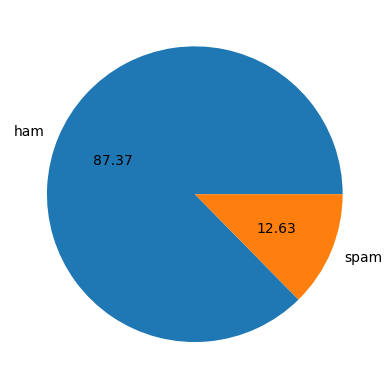

In [18]:
import matplotlib.pyplot  as plt 
plt.pie(data["target"].value_counts() , labels = ["ham" , "spam" ] , autopct ="%0.2f")

In [19]:
# data is imbalance 

In [20]:
! pip install nltk

In [21]:
import nltk 

In [22]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91862\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\91862\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91862\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
data["num_characters"]= data["text"].apply(len)

In [24]:
 # num of words 
 data["num_words"] = data["text"].apply(lambda x: len(nltk.word_tokenize(x)))

In [25]:
data.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [26]:
# number of sentences 

data["num_sentences"] = data["text"].apply(lambda x : len(nltk.sent_tokenize(x)))

In [27]:
data.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
data[['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# ham messages 
data[data['target']==0][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# spam messages

data[data['target']==1][['num_characters' , 'num_words' , 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

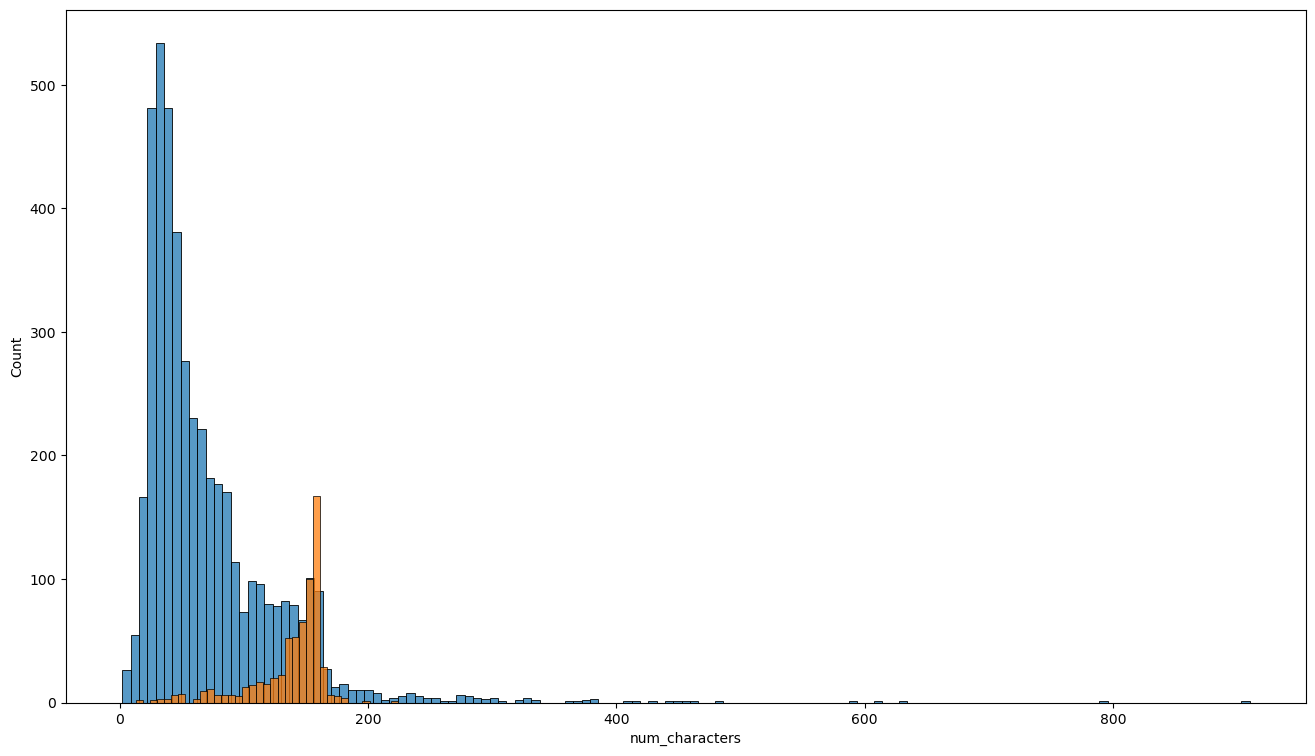

In [31]:
# plot histogram 
import seaborn as sns 
plt.figure(figsize= (16,9))
sns.histplot(data[data['target']==0]['num_characters'])
sns.histplot(data[data['target']==1]['num_characters'])

<Axes: xlabel='num_words', ylabel='Count'>

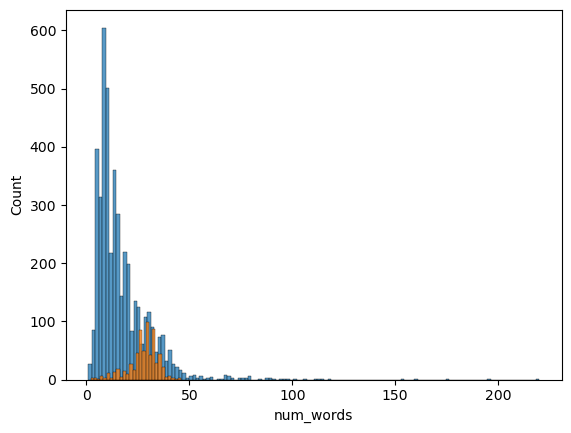

In [32]:
sns.histplot(data[data['target']==0]['num_words'])
sns.histplot(data[data['target']==1]['num_words'])

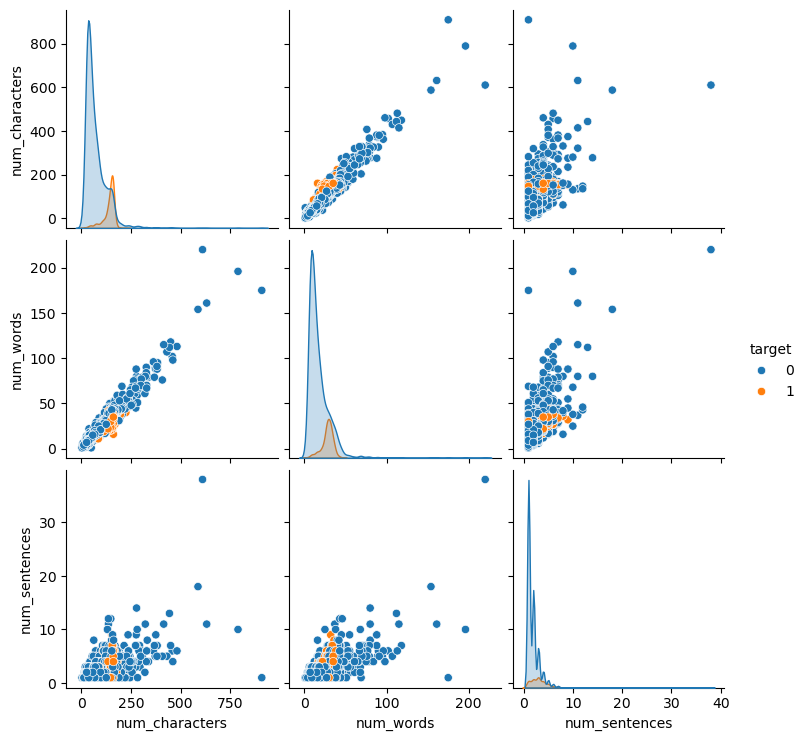

In [33]:
sns.pairplot(data , hue ="target")

<Axes: >

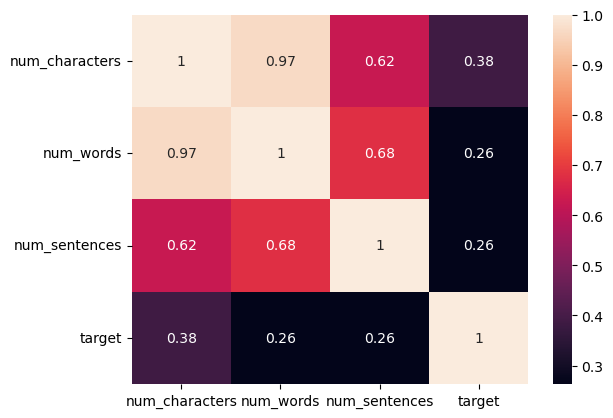

In [34]:
sns.heatmap(data[["num_characters" ,"num_words"	,"num_sentences", "target"]].corr() , annot = True)

 # data processing 

In [35]:
#lower case 
# tokenize 
# removing  special characters 
# removing stop words and punctate 
# stemming 

In [36]:
from nltk.corpus import stopwords
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [37]:
import string 
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [38]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
ps.stem("hapiness")

'hapi'

In [39]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text :
        if i.isalnum():
            y.append(i)
    text = y.copy() 
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y.copy() 
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

    
    
    
        
    

In [40]:
data['transform_text']= data["text"].apply(transform_text)

In [41]:
data.head()

,target,text,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# now  create a word cloud 

In [42]:
! pip install wordcloud

In [43]:

from wordcloud import WordCloud
wc= WordCloud (width = 500 , height = 500 , min_font_size = 10 , background_color ='white')

In [44]:
spam_wc = wc.generate(data[data["target"]==1]["transform_text"].str.cat(sep = ' ' ))

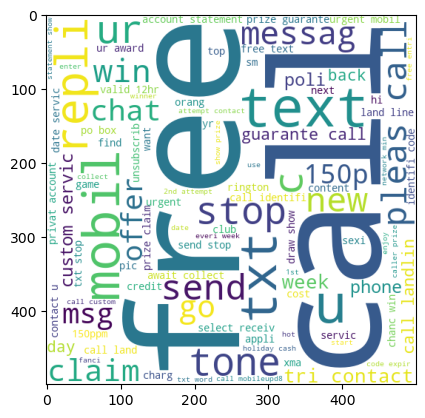

In [45]:
plt.imshow(spam_wc)

In [46]:
ham_wc = wc.generate(data[data["target"]==0]["transform_text"].str.cat(sep = ' ' ))

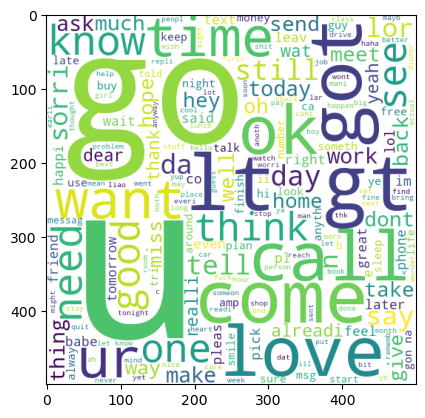

In [47]:
plt.imshow(ham_wc)

#   we are finidng the top 30 words in spam or ham that we can see 


In [48]:
spam_corpus = []

for msg in data[data["target"]==1]["transform_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [49]:
len(spam_corpus)

9939

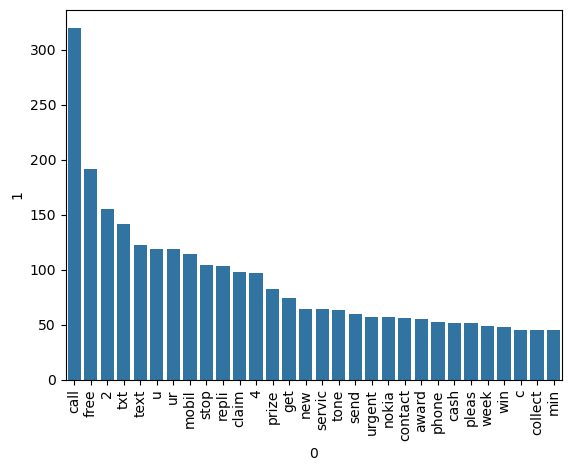

In [50]:
from collections import Counter
df1 = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x = df1[0] , y =  df1[1])
plt.xticks(rotation ='vertical')
plt.show()

In [51]:
ham_corpus = []

for msg in data[data["target"]==0]["transform_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

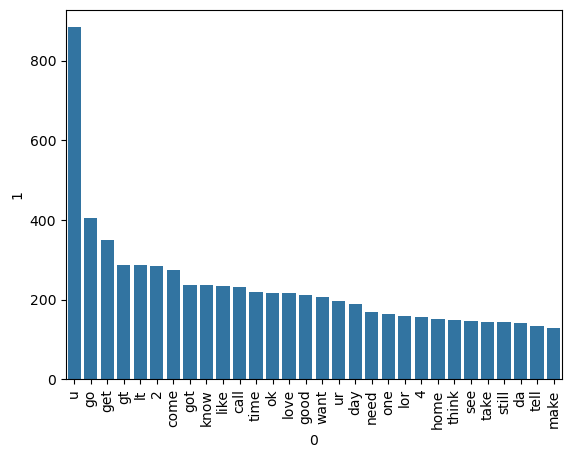

In [52]:
df2 = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x = df2[0] , y =  df2[1])
plt.xticks(rotation ='vertical')
plt.show()

# MODEL BUILDING 

In [53]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer 
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features = 3000)

In [54]:
import numpy as np 
X = tfidf.fit_transform(data['transform_text'])

In [55]:
y = data['target'].values


In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size =0.2 , random_state = 42)

In [58]:
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import accuracy_score , confusion_matrix , precision_score

[[888   1]
 [ 27 118]]
accu_score 0.9729206963249516
prec_score 0.9915966386554622


In [62]:
# here precison score matters more so we go through with tfidf with mnb 

In [63]:
# model improve 
# 1. change  the max feature parameter of the tfidf 

In [80]:
# voting classifier 
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

svc = SVC(kernel = 'sigmoid' , gamma =1.0 , probability= True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators = 50 , random_state = 2)
from  sklearn.ensemble import VotingClassifier

In [81]:
voting = VotingClassifier(estimators =[('svm' , svc) , ('nb' , mnb) , ('et' , etc)] , voting ='soft')

In [82]:
voting.fit(X_train , y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [83]:
y_pred = voting.predict(X_test)
print("Accuracy" , accuracy_score(y_test, y_pred))
print("precision" , precision_score(y_test, y_pred))

Accuracy 0.9816247582205029
precision 0.9921875


In [84]:
import pickle 
pickle.dump(tfidf , open('vectorizer.pkl' , 'wb'))
pickle.dump(voting , open('model.pkl' , 'wb'))